In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

**Trying on with background subtraction**

In [3]:
reference_image=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(R).png"
test_image=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(T).png"

In [4]:
reference=cv2.imread(reference_image,0)
print(reference.shape)




(1024, 1024)


In [5]:
test=cv2.imread(test_image,0)
print(test.shape)

(1024, 1024)


In [6]:
test=cv2.resize(test,(reference.shape[1],reference.shape[0]))
print(test.shape)

(1024, 1024)


In [7]:
test = cv2.GaussianBlur(test, (5,5), 0)
reference = cv2.GaussianBlur(reference, (5,5), 0)


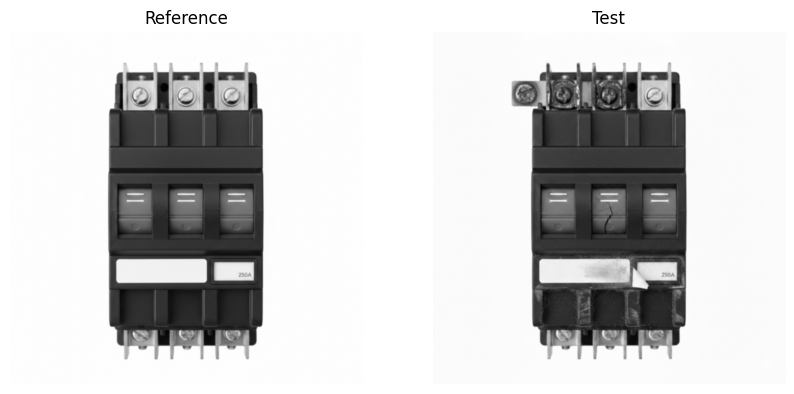

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.imshow(reference,cmap='gray')
ax1.set_title('Reference')
ax2.imshow(test,cmap='gray')
ax2.set_title('Test')
ax1.axis('off')
ax2.axis('off')
plt.show()

In [9]:
diff1=cv2.absdiff(reference,test)
diff0=cv2.absdiff(reference,test)
_,mask=cv2.threshold(diff1,30,255,cv2.THRESH_BINARY)

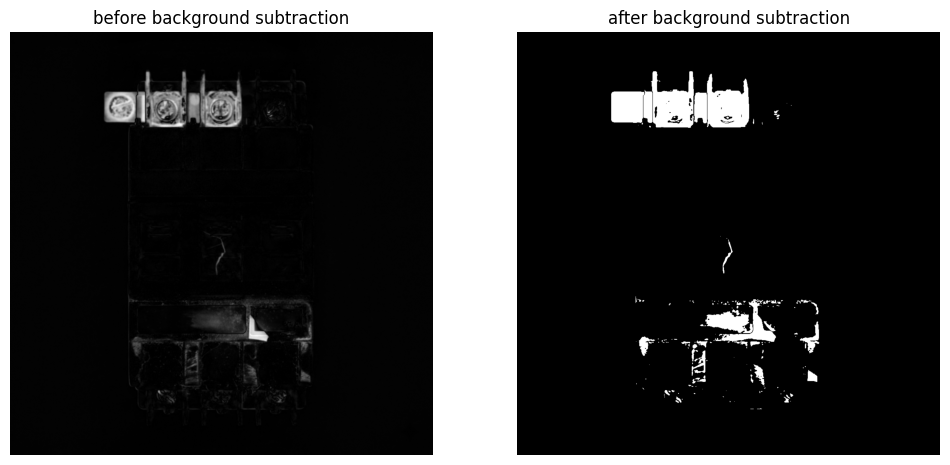

In [10]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,6))
ax1.imshow(diff0,cmap='gray')
ax2.imshow(mask,cmap='gray')
ax1.set_title("before background subtraction")
ax2.set_title("after background subtraction")
ax1.axis('off')
ax2.axis('off')
plt.show()


In [11]:
kernel=np.ones((3,3),np.uint8)
clean_mask=cv2.medianBlur(mask, 5)

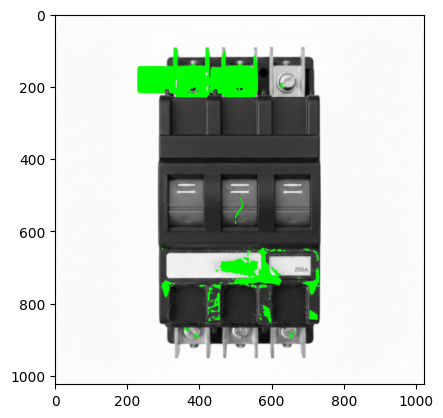

In [12]:
test_color=cv2.cvtColor(test,cv2.COLOR_GRAY2BGR)
test_color[clean_mask==255]=(0,255,0)
plt.imshow(test_color)

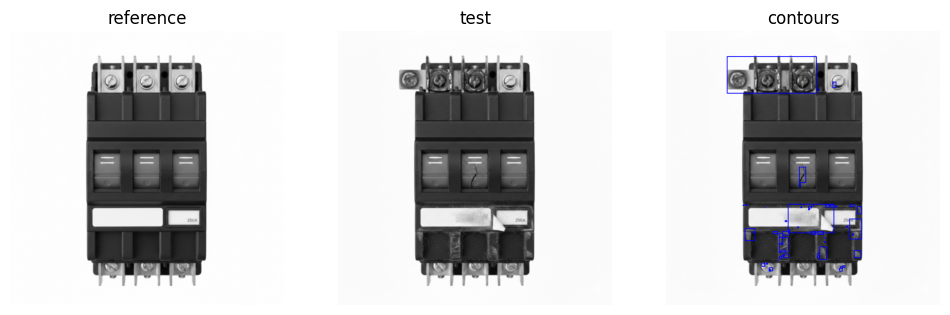

In [13]:
contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
test_color=cv2.cvtColor(test,cv2.COLOR_GRAY2BGR)
for cnt in contours:
    x,y,w,h=cv2.boundingRect(cnt)
    cv2.rectangle(test_color,(x,y),(x+w,y+h),(0,0,255),2)
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(12,6))
ax1.imshow(reference,cmap='gray')
ax2.imshow(test,cmap='gray')
ax3.imshow(test_color)
ax1.set_title("reference")
ax2.set_title("test")
ax3.set_title("contours")
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
plt.show()

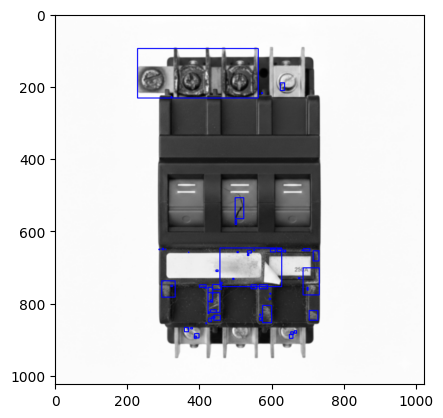

In [14]:
plt.imshow(test_color)
plt.show()

**Gradient difference method**

In [114]:
master_path=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(R).png"
test_path=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(T).png"

In [98]:
master_image=cv2.imread(master_path)
test_image=cv2.imread(test_path)
print(master_image.shape)
print(test_image.shape)


(1024, 1024, 3)
(1024, 1024, 3)


In [99]:
#Resize
master_image=cv2.resize(master_image,(test_image.shape[1],test_image.shape[0]))

In [100]:
#Grayscaling
master_image_gray=cv2.cvtColor(master_image,cv2.COLOR_BGR2GRAY)
test_image_gray=cv2.cvtColor(test_image,cv2.COLOR_BGR2GRAY)

In [101]:
master_blur = cv2.GaussianBlur(master_image_gray, (5,5), 0)
test_blur = cv2.GaussianBlur(test_image_gray, (5,5), 0)

In [102]:
#CLAHE
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
master_gray=clahe.apply(master_image_gray)
test_gray=clahe.apply(test_image_gray)

In [103]:
def gradient_magnitude(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude=cv2.magnitude(sobelx, sobely)
    magnitude=cv2.convertScaleAbs(magnitude)
    return magnitude

In [104]:
master_grad=gradient_magnitude(master_blur)
test_grad=gradient_magnitude(test_blur)

In [105]:
diff=cv2.absdiff(master_grad,test_grad)
_,thresh=cv2.threshold(diff,30,255,cv2.THRESH_BINARY)
thresh=cv2.medianBlur(thresh,5)


In [106]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

In [107]:
contours,_=cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output=test_image.copy()
for i in contours:
    area=cv2.contourArea(i)
    x,y,w,h=cv2.boundingRect(i)
    aspect_ratio=w/float(h)
    if area>200:
        if 0.2 < aspect_ratio < 5.0:
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

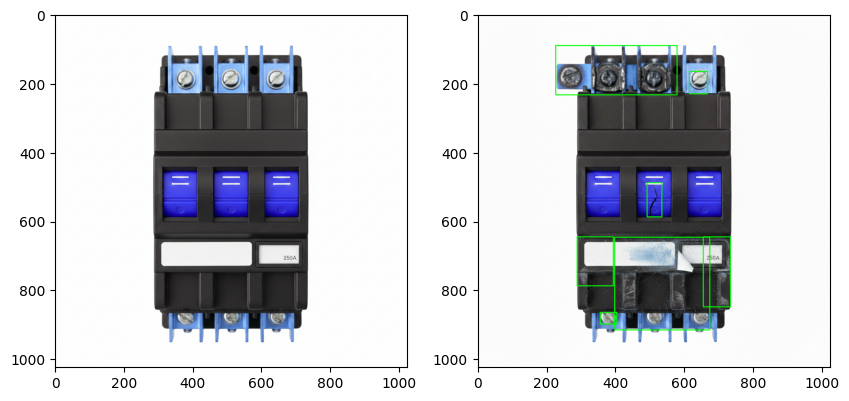

In [108]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))
ax1.imshow(master_image)
ax2.imshow(output)


**Gradient difference pipeline failed since it cannot handle color changes and even converting to grayscale would result in different intensities actually**

**Template Matching**

In [109]:
master_path=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(R).png"
test_path=r"C:\ALL PROJECTS\MCCB-Defect-Detection\images\mccb(T).png"

In [110]:
master_image=cv2.imread(master_path)
test_image=cv2.imread(test_path)

In [112]:
print(master_image.shape,test_image.shape)

(1024, 1024, 3) (1024, 1024, 3)


In [116]:
master_image_gray=cv2.cvtColor(master_image,cv2.COLOR_BGR2GRAY)
test_image_gray=cv2.cvtColor(test_image,cv2.COLOR_BGR2GRAY)

In [119]:
clahe=cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
master_image_clahe=clahe.apply(master_image_gray)
test_image_clahe=clahe.apply(test_image_gray)